In [18]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
diabetes = pd.read_csv('data/diabetes/diabetic_data.csv')

In [11]:
# Clean
diabetes = diabetes.replace({'?': None})
diabetes['readmitted'] = diabetes['readmitted'].replace({'NO': 0, '>30': 1, '<30': 1})
diabetes['diabetesMed'] = diabetes['diabetesMed'].replace({'No': 0, 'Yes': 1})
diabetes['change'] = diabetes['change'].replace({'No': 0, 'Ch': 1})

In [ ]:
def get_rate_table(df, group_col):
    table = df.groupby(group_col).agg(
        total_patients=('readmitted', 'count'),
        readmitted_patients=('readmitted', 'sum')
    )
    table['readmission_rate'] = table['readmitted_patients'] / table['total_patients']
    table['readmission_rate_%'] = table['readmission_rate'] * 100
    return table

gender_table = get_rate_table(diabetes, 'gender')
gender_table

,total_patients,readmitted_patients,readmission_rate,readmission_rate_%
gender,,,,
Female,54708,25670,0.469218,46.92184
Male,47055,21232,0.451217,45.121666
Unknown/Invalid,3,0,0.0,0.0


In [16]:
race_table = get_rate_table(diabetes, 'race')
race_table

,total_patients,readmitted_patients,readmission_rate,readmission_rate_%
race,,,,
AfricanAmerican,19210,8789,0.457522,45.752212
Asian,641,226,0.352574,35.25741
Caucasian,76099,35716,0.469336,46.9336
Hispanic,2037,854,0.419244,41.924399
Other,1506,591,0.39243,39.243028


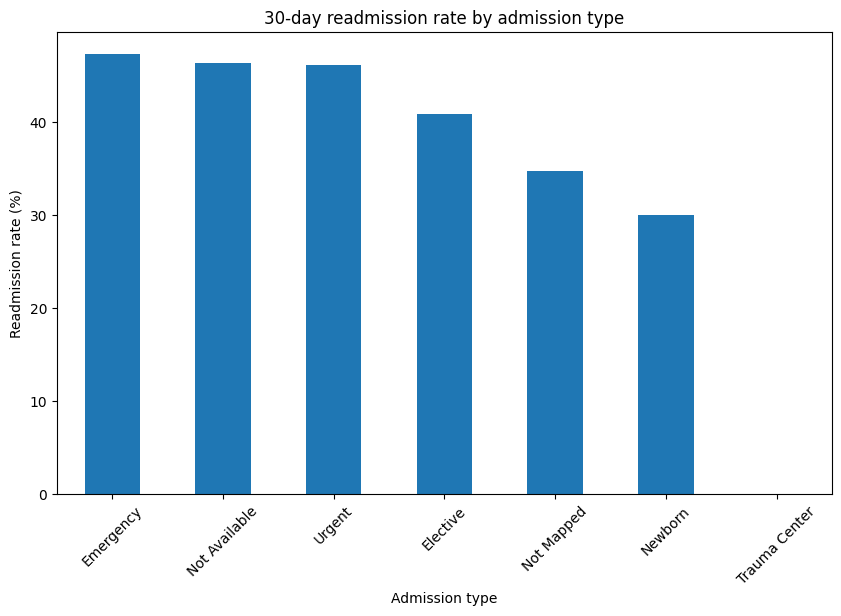

In [22]:
# Load mapping and clean up to get the admission_type descriptions
mapping = pd.read_csv('data/diabetes/IDS_mapping.csv')
# The mapping file often has headers within the rows; we slice for admission_type_id
adm_mapping = mapping.iloc[0:8].rename(columns={'admission_type_id': 'id', 'description': 'admission_name'})
adm_mapping['id'] = adm_mapping['id'].astype(float)

# Merge with main data
diabetes = diabetes.merge(adm_mapping, left_on='admission_type_id', right_on='id', how='left')

# Plotting the bar chart
plt.figure(figsize=(10, 6))
adm_stats = diabetes.groupby('admission_name')['readmitted'].mean() * 100
adm_stats.sort_values(ascending=False).plot(kind='bar')
plt.title('30-day readmission rate by admission type')
plt.ylabel('Readmission rate (%)')
plt.xlabel('Admission type')
plt.xticks(rotation=45)
plt.show()

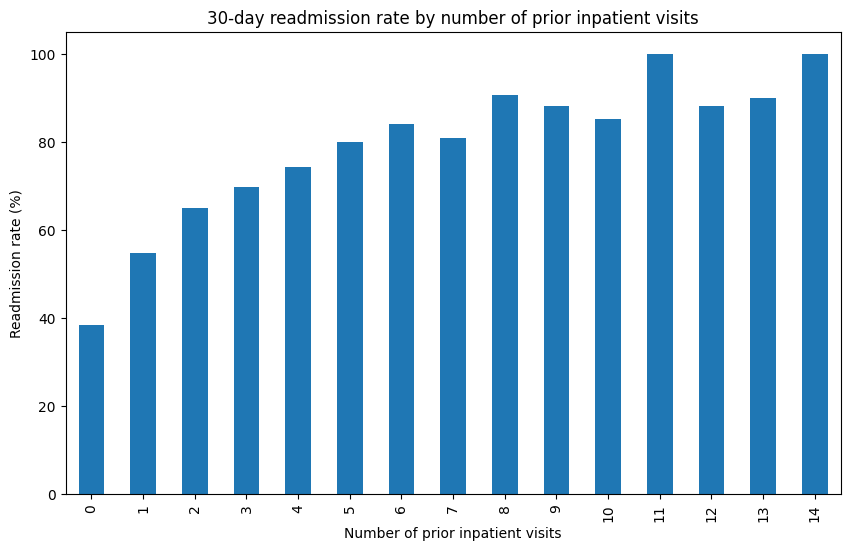

In [24]:
# Grouping by prior inpatient visits (capped at 14 as in the image)
plt.figure(figsize=(10, 6))
inpatient_stats = diabetes[diabetes['number_inpatient'] <= 14].groupby('number_inpatient')['readmitted'].mean() * 100

inpatient_stats.plot(kind='bar', color='tab:blue')
plt.title('30-day readmission rate by number of prior inpatient visits')
plt.ylabel('Readmission rate (%)')
plt.xlabel('Number of prior inpatient visits')
plt.show()